In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
)

# Telco Customer Churn: Model Comparison

The logistic regression baseline is in `modeling.ipynb`. This notebook runs the same pipeline with 4 models to see which one works better.

Models compared: Logistic Regression as baseline, Random Forest, Gradient Boosting and XGBoost. All of them use the same preprocessor so the comparison is valid.

Two passes: first at default threshold 0.5 to get a general overview, then F2 threshold tuning per model for a more fair comparison. AUC-ROC shows which model has more discriminative power and F2 optimisation tells where to set the threshold when recall matters more than precision.

---
## 1. Data

In [2]:
try:
    teleco_data = pd.read_csv('teleco_model_ready.csv')
    print(f'Loaded: {teleco_data.shape}')
except FileNotFoundError:
    print('File not found. Run ppp_v2.ipynb first to generate teleco_model_ready.csv')

Loaded: (7043, 16)


---
## 2. Train/test split

Same split as `modeling.ipynb`: 80/20, stratified and same random state. Train and test sets are identical for all models.

In [3]:
X = teleco_data.drop('Churn', axis=1)
y = teleco_data['Churn'].map({'Yes': 1, 'No': 0})  # XGBoost requires numeric labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Churn rate train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}')

Train: (5634, 15)  |  Test: (1409, 15)
Churn rate train: 26.54%  |  test: 26.54%


---
## 3. Preprocessor

Same `ColumnTransformer` as the baseline. Numeric columns scaled with `StandardScaler` and categoricals one-hot encoded with `drop='if_binary'`.

`drop='if_binary'` drops one level only for Yes/No binary features, while multi-category features like `Contract` and `InternetService` keep all levels. Using `drop='first'` instead causes XGBoost to output NaN probabilities because unknown categories at test time produce all-zero vectors that become ambiguous when one level has been dropped.

Tree models don't actually need scaling since they split on thresholds and are not affected by feature magnitude, but keeping it consistent across all models makes the comparison simpler without hurting them.

In [4]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print(f'Numeric    : {num_cols}')
print(f'Categorical: {cat_cols}')

# drop='if_binary' only drops one level for Yes/No columns.
# Multi-category features (Contract, InternetService, etc.) keep all levels.
# This avoids the all-zero ambiguity that causes XGBoost to produce NaN probabilities.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_cols)
])

Numeric    : ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical: ['Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


---
## 4. Model training and evaluation

The loop trains each model and computes 2 sets of metrics in one pass.

First at default threshold 0.5, which is what you get by default. Useful as a reference but not the actual target of the comparison.

Then at the F2-optimised threshold, which is the one that maximises F2 on the PR curve. F2 weights recall twice as heavy as precision:

$$F2 = rac{5 	imes 	ext{precision} 	imes 	ext{recall}}{4 	imes 	ext{precision} + 	ext{recall}}$$

Missing a churner costs more than a wasted retention offer. We don't have actual cost figures so F2 works as a reasonable proxy when you know recall matters more but can't put a number on it.

Both metrics are stored per model and the comparison is done at each model's own best threshold, not a shared one.

Tree models use `class_weight='balanced'` where available and XGBoost uses `scale_pos_weight` instead, which is the same idea of upweighting churners to compensate for the 27/73 imbalance.

In [5]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos:.2f}')

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=scale_pos, n_estimators=200, random_state=42, eval_metric='logloss'),
}

scale_pos_weight: 2.77


In [6]:
def tune_f2(y_test, probs, beta=2):
    """Find threshold that maximises F2. Returns threshold, precision/recall/F2 at that point, and full curves."""
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, probs, pos_label=1)
    p_arr = precision_curve[:-1]
    r_arr = recall_curve[:-1]
    f2 = (1 + beta**2) * (p_arr * r_arr) / (beta**2 * p_arr + r_arr)
    best_idx = np.argmax(f2)
    return thresholds[best_idx], p_arr[best_idx], r_arr[best_idx], f2[best_idx], precision_curve, recall_curve


results = []
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe

    probs  = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    # default threshold
    f1_def = f1_score(y_test, y_pred, pos_label=1)
    auc    = roc_auc_score(y_test, probs)

    # F2-optimised threshold
    best_thr, pre_tuned, rec_tuned, f2_best, p_curve, r_curve = tune_f2(y_test, probs)
    f1_tuned = f1_score(y_test, (probs >= best_thr).astype(int), pos_label=1)

    results.append({
        'Model':      name,
        'AUC-ROC':    auc,
        'F1 (0.5)':   f1_def,
        'Threshold':  best_thr,
        'F2 (tuned)': f2_best,
        'F1 (tuned)': f1_tuned,
        'Precision':  pre_tuned,
        'Recall':     rec_tuned,
        '_probs':     probs,
        '_p_curve':   p_curve,
        '_r_curve':   r_curve,
    })
    print(f'{name:<25}  AUC={auc:.3f}  F1@0.5={f1_def:.3f}  thr={best_thr:.3f}  F2={f2_best:.3f}  F1={f1_tuned:.3f}  P={pre_tuned:.3f}  R={rec_tuned:.3f}')

results_df = pd.DataFrame(results).sort_values('F2 (tuned)', ascending=False)
print()
display_cols = ['Model', 'AUC-ROC', 'F1 (0.5)', 'Threshold', 'F2 (tuned)', 'F1 (tuned)', 'Precision', 'Recall']
print(results_df[display_cols].to_string(index=False))

Logistic Regression        AUC=0.838  F1@0.5=0.616  thr=0.321  F2=0.755  F1=0.595  P=0.440  R=0.920


Random Forest              AUC=0.809  F1@0.5=0.518  thr=0.115  F2=0.729  F1=0.562  P=0.406  R=0.909


Gradient Boosting          AUC=0.840  F1@0.5=0.569  thr=0.107  F2=0.754  F1=0.583  P=0.424  R=0.936


XGBoost                    AUC=0.811  F1@0.5=0.569  thr=0.056  F2=0.730  F1=0.565  P=0.410  R=0.906

              Model  AUC-ROC  F1 (0.5)  Threshold  F2 (tuned)  F1 (tuned)  Precision   Recall
Logistic Regression 0.837699  0.616193   0.320614    0.755048    0.595156   0.439898 0.919786
  Gradient Boosting 0.840489  0.568862   0.107103    0.753661    0.583333   0.423729 0.935829
            XGBoost 0.810879  0.569307   0.056020    0.729660    0.564530   0.409915 0.906417
      Random Forest 0.808882  0.518409   0.115000    0.728676    0.561519   0.406213 0.909091


---
## 5. Results

The table shows all 4 models with both default (0.5) and F2-tuned metrics. Bar charts show tuned F1 and AUC-ROC side by side.

AUC-ROC ranks models by discriminative power independently of threshold, so a model with low F1 at 0.5 but high AUC can still win after tuning because the signal is there and the default threshold is just suppressing it.

If Logistic Regression holds well against tree models it means the signal is mostly linear. The main predictors (`Contract`, `tenure`, `MonthlyCharges`) have a fairly straightforward relationship with churn that a linear model can exploit directly, while tree models need to find the same structure split by split and on ~5.6k training rows they don't have enough data to do better.

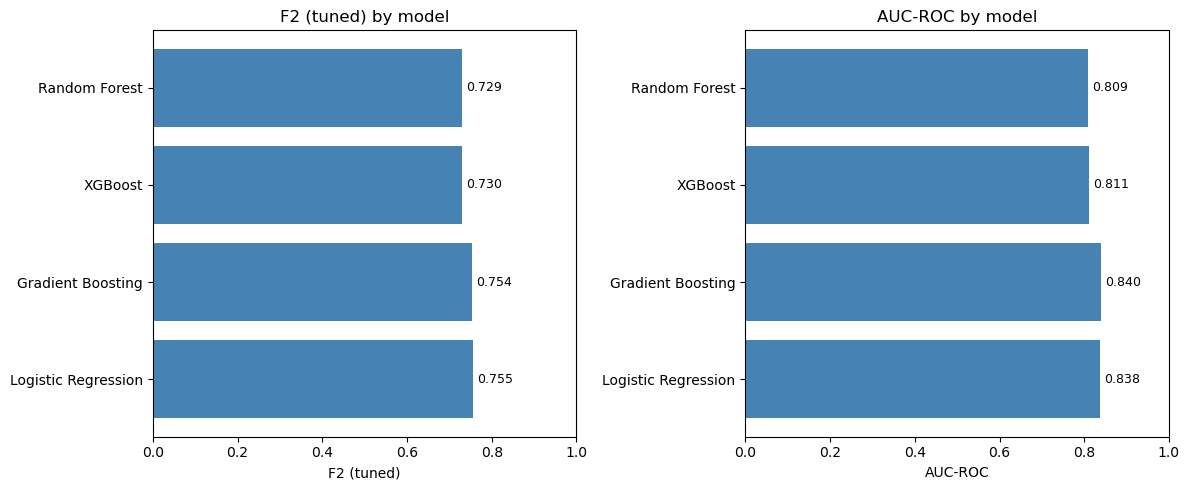

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['F2 (tuned)', 'AUC-ROC']):
    ax.barh(results_df['Model'], results_df[metric], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by model')
    ax.set_xlim(0, 1)
    for i, v in enumerate(results_df[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Cross-validation

A single train/test split can get lucky or unlucky depending on which rows end up where. 5-fold stratified CV splits the data 5 times and averages the results, so if scores are consistent across folds the ranking is real and not just an artifact of one particular split.

AUC-ROC is used here because it's threshold-independent and gives a stable signal across folds without needing to fix a cutoff.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Model":<25}  {"Mean AUC":>9}  {"Std":>6}  Folds')
print('-' * 70)

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    fold_str = '  '.join([f'{s:.3f}' for s in scores])
    print(f'{name:<25}  {scores.mean():>9.3f}  {scores.std():>6.3f}  [{fold_str}]')

Model                       Mean AUC     Std  Folds
----------------------------------------------------------------------


Logistic Regression            0.842   0.013  [0.854  0.841  0.860  0.823  0.834]


Random Forest                  0.814   0.014  [0.826  0.818  0.830  0.792  0.802]


Gradient Boosting              0.843   0.011  [0.857  0.840  0.853  0.830  0.833]


XGBoost                        0.809   0.014  [0.830  0.803  0.819  0.790  0.806]


---
## 7. PR curves

Each curve shows precision vs recall at every threshold. The red dot marks the F2-optimised operating point for that model and the grey dashed line is the no-skill baseline, a random classifier at the dataset's churn rate.

The shape matters: a model that stays high and flat over a wide recall range gives more flexibility to trade precision for recall. If the curve drops steeply it means you pay a high precision cost for every gain in recall.

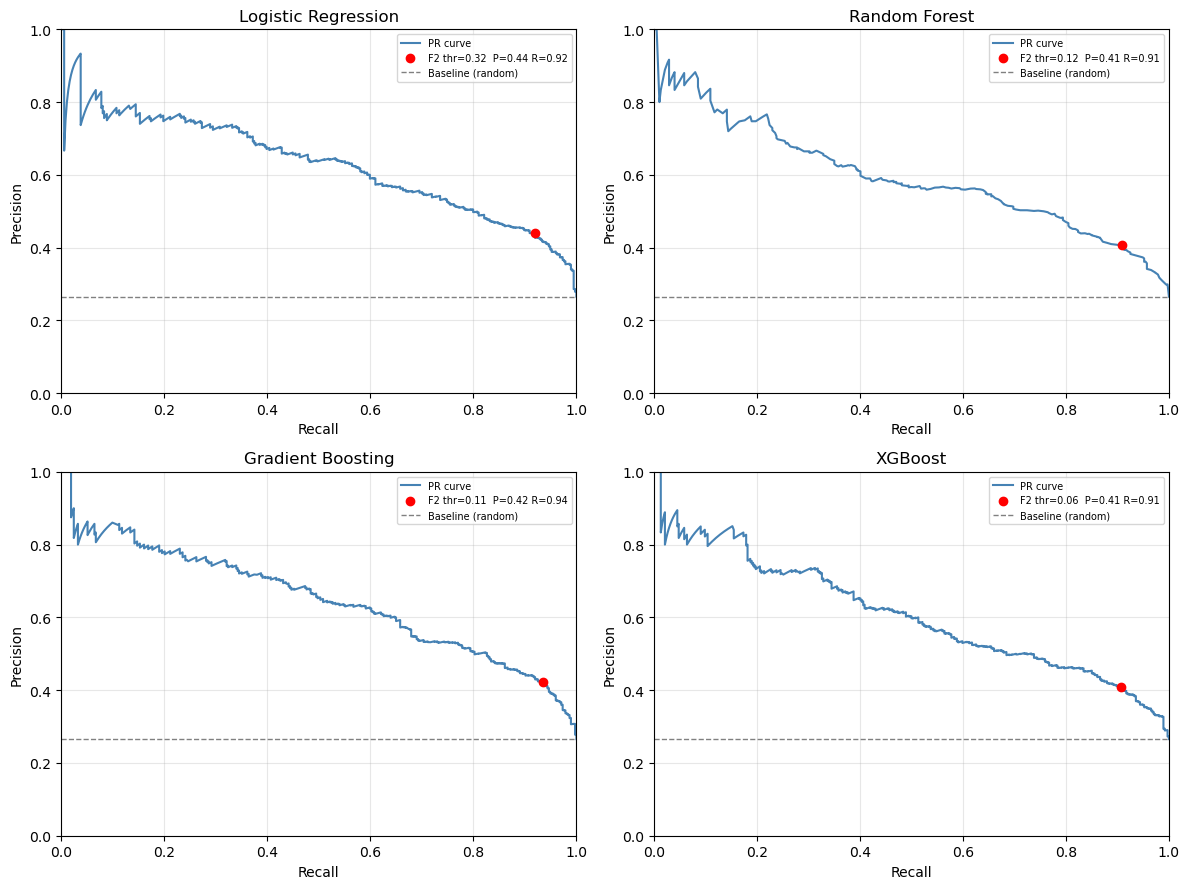

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, row in zip(axes, results):
    name      = row['Model']
    p_curve   = row['_p_curve']
    r_curve   = row['_r_curve']
    thr       = row['Threshold']
    probs     = row['_probs']

    # operating point at best F2 threshold
    y_tuned = (probs >= thr).astype(int)
    p_op = precision_score(y_test, y_tuned, pos_label=1)
    r_op = recall_score(y_test, y_tuned, pos_label=1)

    ax.plot(r_curve, p_curve, color='steelblue', lw=1.5, label='PR curve')
    ax.scatter(r_op, p_op, color='red', zorder=5, label=f'F2 thr={thr:.2f}  P={p_op:.2f} R={r_op:.2f}')
    ax.axhline(y_test.mean(), color='grey', linestyle='--', lw=1, label='Baseline (random)')
    ax.set_title(name)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Feature importance

Tree models expose `feature_importances_` directly. For Logistic Regression, absolute coefficient values are used instead. Both show which features the model relied on the most, though the scales are different and you can't compare them across models — only the ranking within each model is meaningful.

Top 15 features per model.

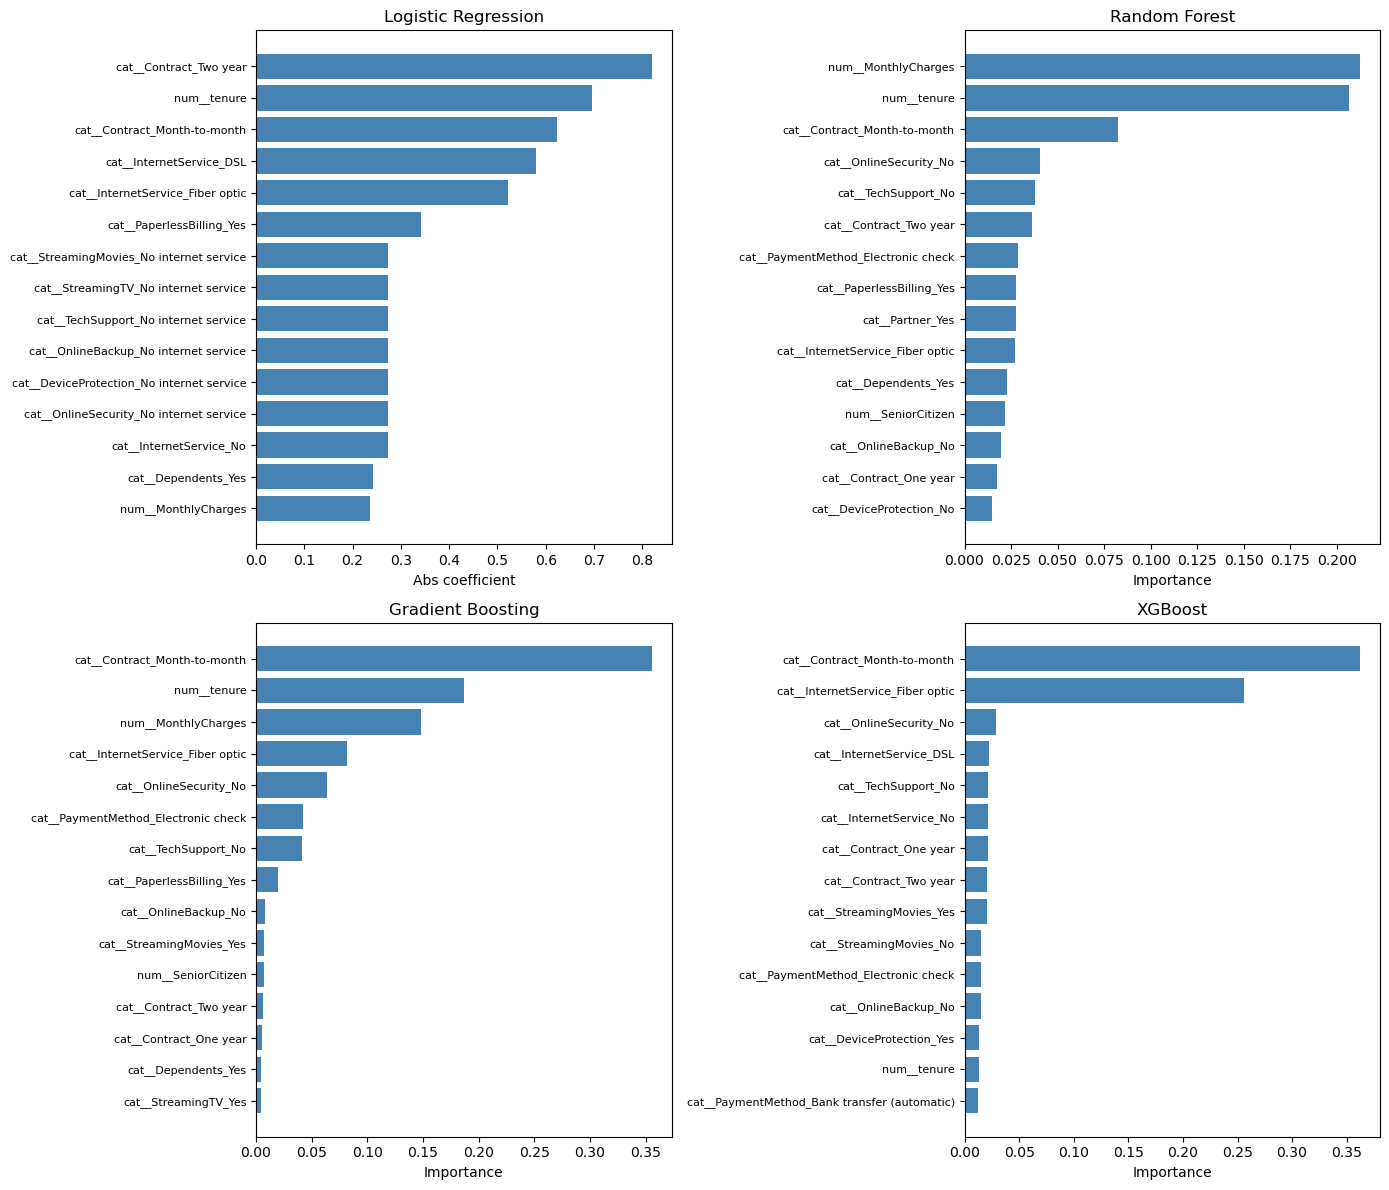

In [10]:
feature_names = fitted_pipes['Random Forest'].named_steps['preprocessor'].get_feature_names_out()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, name in zip(axes, fitted_pipes):
    model = fitted_pipes[name].named_steps['model']

    if hasattr(model, 'feature_importances_'):
        scores = model.feature_importances_
        xlabel = 'Importance'
    else:
        scores = np.abs(model.coef_[0])
        xlabel = 'Abs coefficient'

    imp_df = pd.DataFrame({'feature': feature_names, 'score': scores})
    imp_df = imp_df.nlargest(15, 'score').sort_values('score')

    ax.barh(imp_df['feature'], imp_df['score'], color='steelblue')
    ax.set_title(name)
    ax.set_xlabel(xlabel)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [11]:
best_name = results_df.iloc[0]['Model']
best_thr  = results_df.iloc[0]['Threshold']
best_pipe = fitted_pipes[best_name]

probs_best    = best_pipe.predict_proba(X_test)[:, 1]
y_pred_best   = best_pipe.predict(X_test)
y_tuned_best  = (probs_best >= best_thr).astype(int)

print(f'Best model : {best_name}')
print(f'F2 threshold: {best_thr:.4f}')
print()
print('--- Default threshold (0.5) ---')
print(classification_report(y_test, y_pred_best))
print('--- F2-tuned threshold ---')
print(classification_report(y_test, y_tuned_best))

Best model : Logistic Regression
F2 threshold: 0.3206

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

--- F2-tuned threshold ---
              precision    recall  f1-score   support

           0       0.95      0.58      0.72      1035
           1       0.44      0.92      0.60       374

    accuracy                           0.67      1409
   macro avg       0.70      0.75      0.66      1409
weighted avg       0.82      0.67      0.69      1409



---
## 9. Best model: deep dive

Full classification report and confusion matrix for the best model at its F2-optimised threshold.

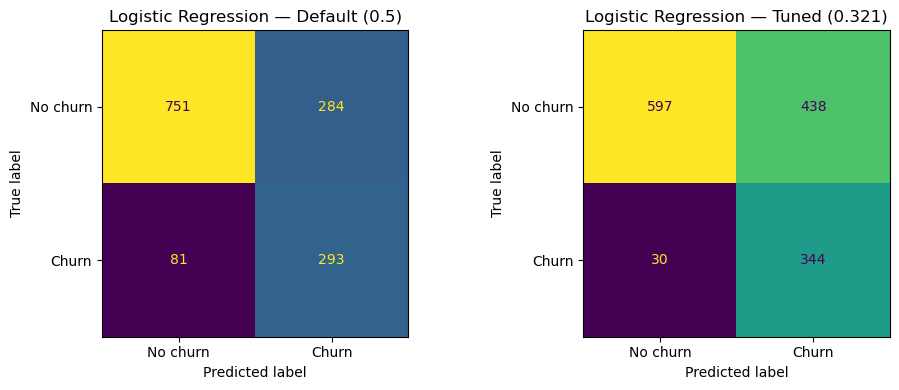

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_p, title in zip(axes,
                           [y_pred_best, y_tuned_best],
                           [f'Default (0.5)', f'Tuned ({best_thr:.3f})']):
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{best_name} — {title}')

plt.tight_layout()
plt.show()

In [13]:
import joblib

joblib.dump({"pipeline": best_pipe, "threshold": best_thr}, "best_model.pkl")
print(f"Saved: {best_name}  |  threshold: {best_thr:.4f}")

Saved: Logistic Regression  |  threshold: 0.3206


---
## 10. Conclusion

The table below shows the final ranking with each model at its own F2-optimised threshold.

LR wins because the main churn predictors — contract type, tenure and monthly charges — have a roughly linear relationship with the outcome and LR exploits that directly. Tree models need to reconstruct the same structure split by split, and on roughly 5,600 training rows they don't have enough data to do better. This is not a failure of the tree models, it's just what this dataset supports.

When 2 models come out similar on AUC-ROC and F2 the right choice is the simpler one. LR trains in milliseconds, there is nothing meaningful to tune and the coefficients tell you directly which features are pushing the prediction. A tree ensemble that matches LR on every metric adds complexity without any benefit.

No grid search was done because LR already matches or beats everything at defaults so there is no gap to close. Grid search makes sense when you have a clear second-best candidate that looks undertrained, which is not the case here.

CV confirms the result is not just a lucky draw from one split. Running the same comparison across 5 subsets with consistent mean AUC and low spread shows the ranking is stable.

One thing worth keeping in mind: the F2 threshold is a proxy calibrated to F2's recall/precision trade-off and not to actual business costs. If you ever have real figures for what a missed churner costs vs a wasted retention call, recomputing the threshold from the cost matrix would give a more precise cutoff than just maximising F2.

In [14]:
print('=== All models: default vs F2-tuned threshold ===\n')
print(f'{"Model":<25}  {"AUC":>6}  {"F1@0.5":>7}  {"Thr":>6}  {"F2":>6}  {"F1@F2":>7}  {"P":>6}  {"R":>6}')
print('-' * 80)
for _, row in results_df.iterrows():
    print(f'{row["Model"]:<25}  {row["AUC-ROC"]:>6.3f}  {row["F1 (0.5)"]:>7.3f}  {row["Threshold"]:>6.3f}  {row["F2 (tuned)"]:>6.3f}  {row["F1 (tuned)"]:>7.3f}  {row["Precision"]:>6.3f}  {row["Recall"]:>6.3f}')

best = results_df.iloc[0]
print(f'\nBest model by F2: {best["Model"]}  (F2={best["F2 (tuned)"]:.3f}, Recall={best["Recall"]:.3f})')

=== All models: default vs F2-tuned threshold ===

Model                         AUC   F1@0.5     Thr      F2    F1@F2       P       R
--------------------------------------------------------------------------------
Logistic Regression         0.838    0.616   0.321   0.755    0.595   0.440   0.920
Gradient Boosting           0.840    0.569   0.107   0.754    0.583   0.424   0.936
XGBoost                     0.811    0.569   0.056   0.730    0.565   0.410   0.906
Random Forest               0.809    0.518   0.115   0.729    0.562   0.406   0.909

Best model by F2: Logistic Regression  (F2=0.755, Recall=0.920)
